In [1]:
!git remote add origin https://github.com/rachanapra77-netizen/telco-customer-churn.git
!git branch -M main
!git push -u origin main

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [1]:
!pip install xgboost

# Telco Customer Churn - Segmentation & Prediction
Predict which telecom customers will churn, and segment the customer base for targeted retention.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

## Data Cleaning
- 7043 customers, 21 columns, target: Churn (27% yes - imbalanced)
- Fixed TotalCharges: it was text (object) because 11 new customers (tenure=0) had blank values.      Converted to numeric and filled with 0.

In [4]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [8]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [9]:
df[df['TotalCharges'] == ' ']['tenure']

488     0
753     0
936     0
1082    0
1340    0
3331    0
3826    0
4380    0
5218    0
6670    0
6754    0
Name: tenure, dtype: int64

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [12]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [13]:
df['TotalCharges'].dtype

dtype('float64')

In [14]:
df.shape

(7043, 21)

In [15]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [16]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [17]:
df['Contract'].value_counts() 

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

## Encoding
Used get_dummies to convert 18 text columns to numeric (one-hot), avoiding fake ordering. Dropped customerID (just an identifier).

In [18]:
df = df.drop('customerID', axis=1)

In [19]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.shape
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [20]:
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

In [21]:
X.shape
y.value_counts()

Churn_Yes
False    5174
True     1869
Name: count, dtype: int64

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
X_scaled.shape
X_scaled[:2]

array([[-0.43991649, -1.27744458, -1.16032292, -0.99261052, -1.00955867,
         1.03453023, -0.65401193, -3.05401039,  3.05401039, -0.85417615,
        -0.88565976, -0.52592737, -0.52592737, -0.63393298, -0.52592737,
         1.3782406 , -0.52592737, -0.72396752, -0.52592737, -0.63943864,
        -0.52592737, -0.79013171, -0.52592737, -0.79607014, -0.51424938,
        -0.56297505,  0.8297975 , -0.52504733,  1.40641839, -0.54480692],
       [-0.43991649,  0.06632742, -0.25962894, -0.17216471,  0.99053183,
        -0.96662231, -0.65401193,  0.32743831, -0.32743831, -0.85417615,
        -0.88565976, -0.52592737, -0.52592737,  1.57745383, -0.52592737,
        -0.72556272, -0.52592737,  1.38127743, -0.52592737, -0.63943864,
        -0.52592737, -0.79013171, -0.52592737, -0.79607014,  1.94458183,
        -0.56297505, -1.20511329, -0.52504733, -0.71102597,  1.83551265]])

## Customer Segmentation (K-Means)
Scaled features (K-Means uses distance). Elbow method -> k=3.
Three segments found:
- Cluster 0: loyal high-value (55 months, $89/mo)
- Cluster 1: budget users (lowest spend, most loyal)
- Cluster 2: new customers (16 months)

Retention budget should focus on new customers in their first 16 months (onboarding, early engagement).

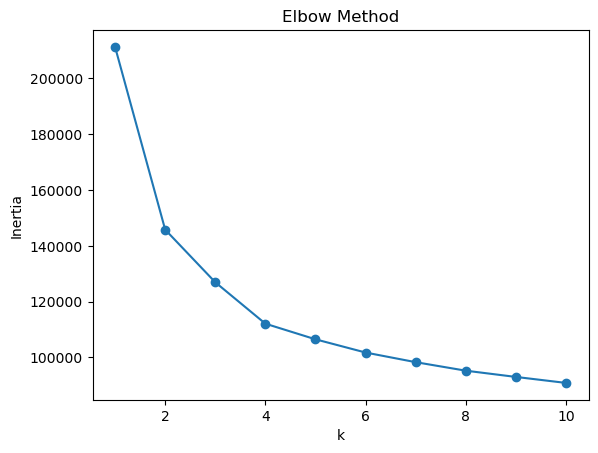

In [24]:
from sklearn.cluster import KMeans

inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()  

In [25]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters
df['Cluster'].value_counts()

Cluster
2    3149
0    2368
1    1526
Name: count, dtype: int64

In [26]:
df.groupby('Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

,tenure,MonthlyCharges,TotalCharges
Cluster,,,
0,55.082770,89.426394,4930.284903
1,30.547182,21.079194,662.604784
2,16.176246,67.382677,1070.218847


In [27]:
df.groupby('Cluster')['Churn'].value_counts(normalize=True)

Cluster  Churn
0        No       0.847128
         Yes      0.152872
1        No       0.925950
         Yes      0.074050
2        No       0.557320
         Yes      0.442680
Name: proportion, dtype: float64

## Visualization (PCA)
Reduced 30 features to 2D. Explained variance = 45% (low because 30 features), so this is an approximation - clusters are defined in full 30D space.

Explained variance: 0.45163604610032193


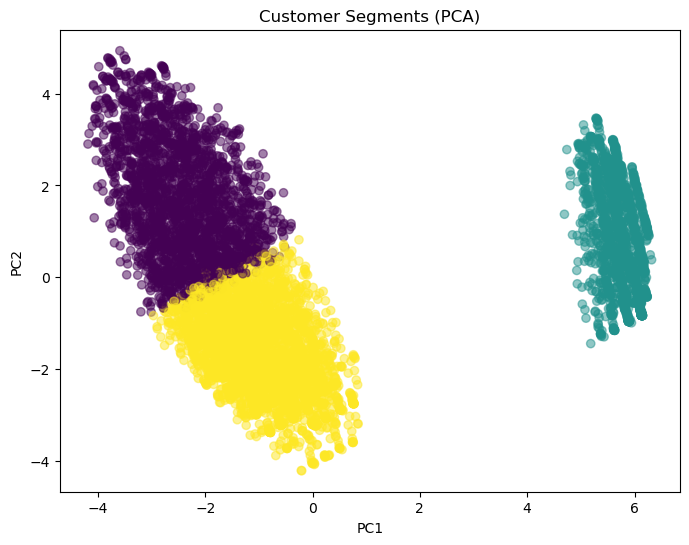

In [28]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segments (PCA)')
plt.show()

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(5634, 30) (1409, 30)
Churn_Yes
False    0.734647
True     0.265353
Name: proportion, dtype: float64


In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
X_train_scaled.shape

(5634, 30)

## Churn Prediction
Stratified split (kept 27% churn ratio). Scaling fit only on train (no leakage). Handled imbalance with class_weight/scale_pos_weight. Used ROC-AUC + recall (not accuracy — it misleads on imbalanced data).

| Model | ROC-AUC | Churn Recall |
|---|---|---|
| Logistic Regression | 0.84 | 0.79 |
| Random Forest | 0.82 | 0.49 |
| XGBoost | 0.82 | 0.68 |

Logistic Regression won — Churn is roughly linearly separable here, so the simple model captures it well. For catching churners, recall matters most — and Logistic had the best recall (0.79). 


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

logreg = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.8414012245214291
              precision    recall  f1-score   support

       False       0.90      0.72      0.80      1035
        True       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("RF ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

RF ROC-AUC: 0.8224495595339585
              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1035
        True       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [35]:
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=3, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]
y_pred_xgb = xgb.predict(X_test)

print("XGB ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb))

XGB ROC-AUC: 0.8196530522617479
              precision    recall  f1-score   support

       False       0.87      0.79      0.83      1035
        True       0.54      0.68      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.71      1409
weighted avg       0.78      0.76      0.77      1409



## Conclusion
- Segmented 7043 customers into 3 groups; new customers are the biggest churn risk (44%).
- Best churn model: Logistic Regression (ROC-AUC 0.84, recall 0.79).
- Recommendation: focus retention on early-lifecycle customers.